In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [4]:
df = pd.read_excel('L005169-082426.xlsx')

print(df.shape)
print(df.head())
print(df.info())

(285858, 17)
  Agency                           ID_Incident           StartDate  \
0     FD  AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD 2011-07-17 00:00:00   
1     FD  5E7D8AA7-872F-4C28-849C-0001031ACCD5 2020-04-08 12:59:00   
2     FD  A9DBA206-FB1E-4061-9500-0001FC0A547D 2009-04-25 00:00:00   
3     FD  E47D6494-9964-4F0A-B4F8-0002615830C7 2008-01-29 00:00:00   
4     FD  7CD8FF55-5E90-450B-8687-0002A206891B 2008-06-17 00:00:00   

            Contained          Controlled   County              FireName  \
0                 NaT                 NaT  Wichita     Rekindle Krohn Rd   
1 2020-04-08 13:16:00 2020-04-08 13:52:00  Aransas                   190   
2                 NaT                 NaT      Bee            Grass Fire   
3                 NaT                 NaT     Bell  7000 Stillman Valley   
4                 NaT                 NaT    Mills        Stone Creek #3   

         Lat       Long  acres             CauseGeneral  \
0  34.091480 -98.898642    0.0             Other c

In [24]:
print(df.isnull().sum())

Agency                      0
ID_Incident                 0
StartDate                   0
Contained              187913
Controlled             183890
County                      0
FireName                  497
Lat                       245
Long                      245
acres                       0
CauseGeneral               50
CauseSpecific             107
CauseSpecificDetail     57472
Department                  0
BadLocation                 0
IrwinID                274802
Shape                       0
dtype: int64


In [25]:
print(df["acres"].describe())

count    2.858580e+05
mean     5.452653e+01
std      3.032380e+03
min     -1.000000e+00
25%      5.000000e-01
50%      1.000000e+00
75%      5.000000e+00
max      1.054153e+06
Name: acres, dtype: float64


In [14]:
print("Minimum acres:", df["acres"].min())
print("Number of negative acres:", (df["acres"] < 0).sum())
print("Number of zero acres:", (df["acres"] == 0).sum())
print("Number of -1 acres:", (df["acres"] == -1).sum())
print("Number of missing acres:", df["acres"].isna().sum())

print("\nProblematic observations:")
print(df.loc[df["acres"] <= 0, ["acres", "StartDate", "FireName"]])

Minimum acres: 0.0
Number of negative acres: 0
Number of zero acres: 13543
Number of -1 acres: 0
Number of missing acres: 0

Problematic observations:
        acres  StartDate                  FireName
561       0.0 1985-08-07           Henderson - 138
1267      0.0 1985-10-05           Henderson - 284
1291      0.0 1985-10-06           Henderson - 297
2641      0.0 1986-03-30           Henderson - 220
3178      0.0 1987-03-04              Conroe - 905
...       ...        ...                       ...
180217    0.0 2014-01-01                14-0010015
180221    0.0 2014-01-01                Stump fire
180231    0.0 2014-01-01              Rubbish fire
180234    0.0 2014-01-01  North Hackberry, 14-0001
180241    0.0 2014-01-01              1680 Mary Dr

[13543 rows x 3 columns]


In [5]:
# Treat -1 acres as missing/invalid
df["acres"] = df["acres"].replace(-1, np.nan)

# Remove observations with unknown target
df = df.dropna(subset=["acres"]).copy()

print(df["acres"].describe())
print("Minimum:", df["acres"].min())
print("Missing:", df["acres"].isna().sum())

count    2.858570e+05
mean     5.452673e+01
std      3.032385e+03
min      0.000000e+00
25%      5.000000e-01
50%      1.000000e+00
75%      5.000000e+00
max      1.054153e+06
Name: acres, dtype: float64
Minimum: 0.0
Missing: 0


In [6]:
df["StartDate"] = pd.to_datetime(
    df["StartDate"],
    errors="coerce"
)

df["StartYear"] = df["StartDate"].dt.year
df["StartMonth"] = df["StartDate"].dt.month
df["StartDayOfYear"] = df["StartDate"].dt.dayofyear

df["StartSeason"] = df["StartDate"].dt.month.map({
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall"
})

In [7]:
df = df.sort_values("StartDate").reset_index(drop=True)
df.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,...,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape,StartYear,StartMonth,StartDayOfYear,StartSeason
0,TFS,F381E111-916D-48D4-BE3E-BA6361B7A767,1985-01-01,1985-01-01 16:30:00,1985-01-01 16:45:00,Shelby,Henderson - 1,31.860416,-94.206253,1.0,...,Origin and/or cause not identified,NaN,Texas A&M Forest Service,0,NaN,0xE6100000010CD11CFE3F338D57C048E4F53F44DC3F40,1985,1,1,Winter
1,TFS,E6434963-0B2A-4358-AD19-9E2AD3C540B1,1985-01-07,1985-01-07 17:47:00,1985-01-07 17:53:00,Cass,Linden - 1,32.927082,-94.056252,5.0,...,Yard debris,Unknown (remarks required),Texas A&M Forest Service,0,NaN,0xE6100000010CCC6C04A0998357C04334FC9FAA764040,1985,1,7,Winter
2,TFS,DF8C228B-3441-40EA-82CE-45FCD59585B3,1985-01-08,1985-01-08 17:50:00,1985-01-08 18:12:00,Caldwell,South Branch - 1,29.831250,-97.435417,8.0,...,Open trash burning,Unknown (remarks required),Texas A&M Forest Service,0,NaN,0xE6100000010CDC0D05E0DD5B58C002D8FCCFCCD43D40,1985,1,8,Winter
3,TFS,49180EAE-79D3-4C62-93EF-5948B6170CC1,1985-01-09,1985-01-09 15:49:00,1985-01-09 16:10:00,Jasper,Woodville - 1,30.297916,-94.056252,8.0,...,Other (remarks required),NaN,Texas A&M Forest Service,0,NaN,0xE6100000010CCC6C04A0998357C048E4F53F444C3E40,1985,1,9,Winter
4,TFS,87601B8C-113D-4E33-9739-1291D8BA5BD8,1985-01-09,1985-01-09 17:02:00,1985-01-09 17:42:00,Tyler,Woodville - 2,31.014584,-94.381248,3.0,...,Other (remarks required),NaN,Texas A&M Forest Service,0,NaN,0xE6100000010C3493FB5F669857C0B81B0AC0BB033F40,1985,1,9,Winter


In [8]:
numeric_features = [
    "Lat",
    "Long",
    "StartYear",
    "StartMonth",
    "StartDayOfYear"
]

categorical_features = [
    "Agency",
    "County",
    "CauseGeneral",
    "CauseSpecific",
    "Department",
    "BadLocation",
    "StartSeason"
]


X = df[numeric_features + categorical_features]

y = df["acres"]

In [9]:
y_log = np.log1p(y)

In [32]:
print("Any infinite values:", np.isinf(y_log).sum())
print("Any missing values:", y_log.isna().sum())

Any infinite values: 0
Any missing values: 0


In [10]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [12]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

In [36]:
tscv = TimeSeriesSplit(n_splits=5)

raw_results = cross_validate(
    linear_model,
    X,
    y,
    cv=tscv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=True
)

In [37]:
raw_mae = -raw_results["test_MAE"]
raw_rmse = -raw_results["test_RMSE"]
raw_r2 = raw_results["test_R2"]

print("Raw Target Linear Regression")
print("-----------------------------")
print("Mean MAE:", raw_mae.mean())
print("Mean RMSE:", raw_rmse.mean())
print("Mean R²:", raw_r2.mean())

Raw Target Linear Regression
-----------------------------
Mean MAE: 254.39309614867835
Mean RMSE: 2865.522470847748
Mean R²: -0.5443540750780619


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

log_mae = []
log_rmse = []
log_r2 = []

for train_idx, test_idx in tscv.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y_log.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Fit model on log-transformed target
    linear_model.fit(X_train, y_train)

    # Predict log(acres + 1)
    y_pred_log = linear_model.predict(X_test)

    # Convert predictions back to acres
    y_pred = np.expm1(y_pred_log)

    # Prevent tiny numerical negative predictions
    y_pred = np.maximum(y_pred, 0)

    # Evaluate in original acreage units
    log_mae.append(
        mean_absolute_error(y_test, y_pred)
    )

    log_rmse.append(
        np.sqrt(mean_squared_error(y_test, y_pred))
    )

    log_r2.append(
        r2_score(y_test, y_pred)
    )

In [39]:
print("Log-Transformed Target Linear Regression")
print("-----------------------------------------")
print("Mean MAE:", np.mean(log_mae))
print("Mean RMSE:", np.mean(log_rmse))
print("Mean R²:", np.mean(log_r2))

Log-Transformed Target Linear Regression
-----------------------------------------
Mean MAE: 58.8623694722221
Mean RMSE: 2745.582803157528
Mean R²: 0.004328312799228584


In [40]:
results_table = pd.DataFrame({
    "Model": [
        "Linear Regression - Raw Target",
        "Linear Regression - Log Target"
    ],
    "Mean MAE": [
        raw_mae.mean(),
        np.mean(log_mae)
    ],
    "Mean RMSE": [
        raw_rmse.mean(),
        np.mean(log_rmse)
    ],
    "Mean R²": [
        raw_r2.mean(),
        np.mean(log_r2)
    ]
})

print(results_table)

                            Model    Mean MAE    Mean RMSE   Mean R²
0  Linear Regression - Raw Target  254.393096  2865.522471 -0.544354
1  Linear Regression - Log Target   58.862369  2745.582803  0.004328


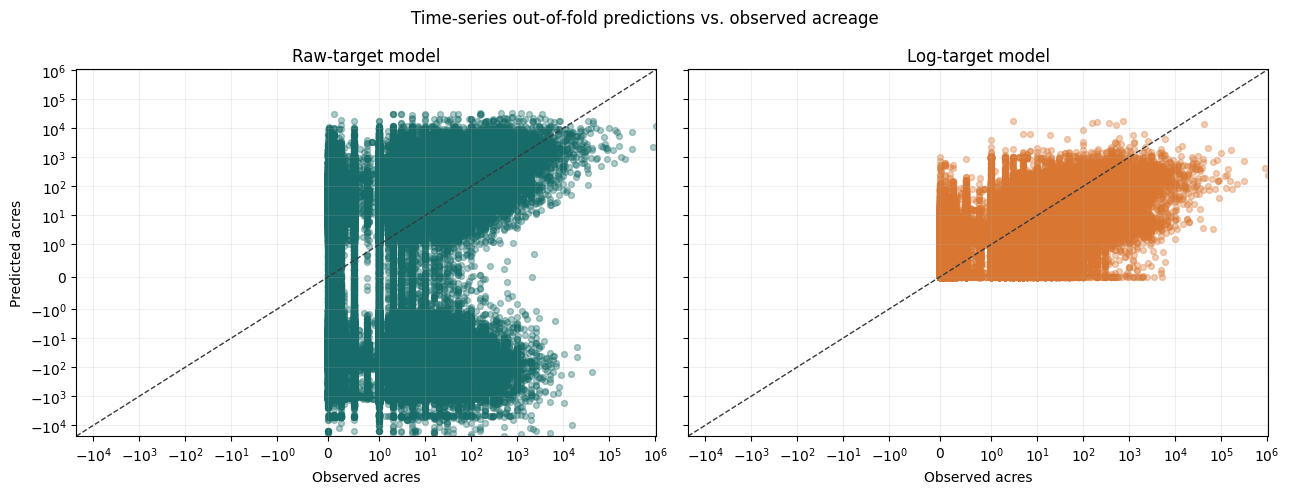

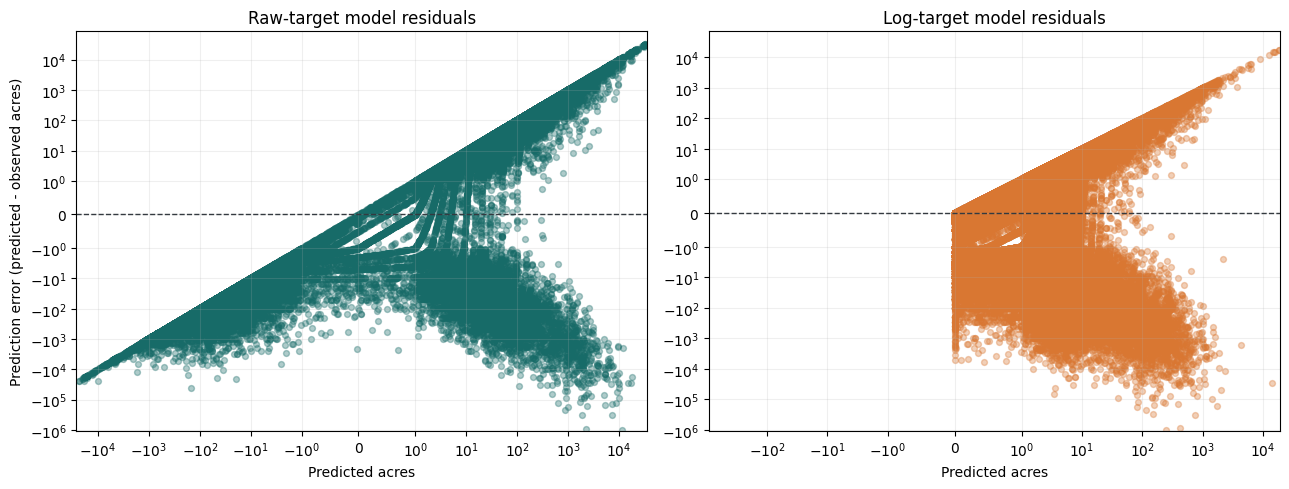

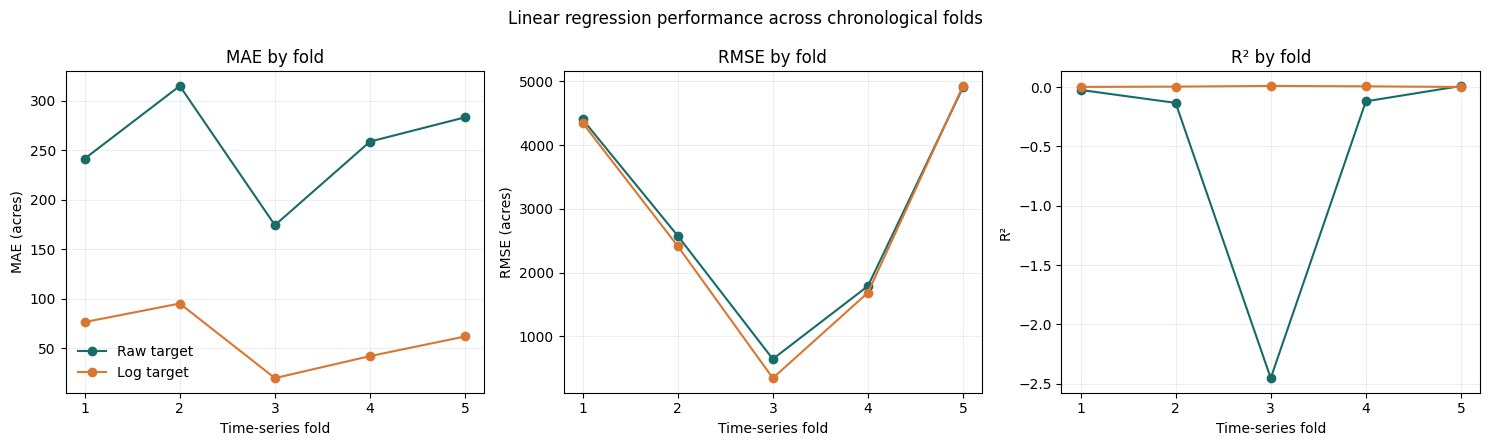

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

raw_oof = np.full(len(y), np.nan)
log_oof = np.full(len(y), np.nan)
raw_mae, raw_rmse, raw_r2 = [], [], []
log_mae, log_rmse, log_r2 = [], [], []
plot_cv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in plot_cv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    raw_fold_model = clone(linear_model)
    raw_fold_model.fit(X_train, y_train)
    raw_predictions = raw_fold_model.predict(X_test)
    raw_oof[test_idx] = raw_predictions
    raw_mae.append(mean_absolute_error(y_test, raw_predictions))
    raw_rmse.append(np.sqrt(mean_squared_error(y_test, raw_predictions)))
    raw_r2.append(r2_score(y_test, raw_predictions))

    log_fold_model = clone(linear_model)
    log_fold_model.fit(X_train, y_log.iloc[train_idx])
    log_predictions = np.maximum(np.expm1(log_fold_model.predict(X_test)), 0)
    log_oof[test_idx] = log_predictions
    log_mae.append(mean_absolute_error(y_test, log_predictions))
    log_rmse.append(np.sqrt(mean_squared_error(y_test, log_predictions)))
    log_r2.append(r2_score(y_test, log_predictions))

observed = y.to_numpy()
scored = np.isfinite(raw_oof) & np.isfinite(log_oof)
fold_number = np.arange(1, len(raw_mae) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_bounds = [
    min(observed[scored].min(), raw_oof[scored].min(), log_oof[scored].min()),
    max(observed[scored].max(), raw_oof[scored].max(), log_oof[scored].max())
]

for ax, predictions, title, color in [
    (axes[0], raw_oof, "Raw-target model", "#176b68"),
    (axes[1], log_oof, "Log-target model", "#d97732")
]:
    ax.scatter(observed[scored], predictions[scored], s=18, alpha=0.35, color=color)
    ax.plot(plot_bounds, plot_bounds, linestyle="--", color="#343a40", linewidth=1)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(plot_bounds)
    ax.set_ylim(plot_bounds)
    ax.set_title(title)
    ax.set_xlabel("Observed acres")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Predicted acres")
fig.suptitle("Time-series out-of-fold predictions vs. observed acreage")
fig.tight_layout()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, predictions, title, color in [
    (axes[0], raw_oof, "Raw-target model residuals", "#176b68"),
    (axes[1], log_oof, "Log-target model residuals", "#d97732")
]:
    residuals = predictions[scored] - observed[scored]
    ax.scatter(predictions[scored], residuals, s=18, alpha=0.35, color=color)
    ax.axhline(0, linestyle="--", color="#343a40", linewidth=1)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_title(title)
    ax.set_xlabel("Predicted acres")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Prediction error (predicted - observed acres)")
fig.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, raw_scores, log_scores, title, ylabel in [
    (axes[0], raw_mae, log_mae, "MAE by fold", "MAE (acres)"),
    (axes[1], raw_rmse, log_rmse, "RMSE by fold", "RMSE (acres)"),
    (axes[2], raw_r2, log_r2, "R² by fold", "R²")
]:
    ax.plot(fold_number, raw_scores, marker="o", label="Raw target", color="#176b68")
    ax.plot(fold_number, log_scores, marker="o", label="Log target", color="#d97732")
    ax.set_title(title)
    ax.set_xlabel("Time-series fold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(fold_number)
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False)
fig.suptitle("Linear regression performance across chronological folds")
fig.tight_layout()

## Results:
Before fitting the linear regression model, several preprocessing steps were performed to make the wildfire data suitable for modeling.

The `StartDate` variable was converted into separate temporal features, including year, month, day of year, and season, because the raw date itself is not directly useful to a linear regression model and wildfire size may vary with time and season.

Numerical predictors such as latitude, longitude, and the extracted time variables were median-imputed when necessary and standardized using `StandardScaler` so that variables with different numerical scales could be placed on a comparable scale.

Categorical variables such as agency, county, cause, department, and season were imputed using the most frequent category and then converted into numerical indicator variables using one-hot encoding, since linear regression cannot directly use categorical text values. The `handle_unknown="ignore"` option was also used so that categories appearing in validation data but not in the training data would not cause the model to fail. These preprocessing steps were included within a pipeline so that the imputation, scaling, and encoding were learned separately within each training fold during time-series cross-validation, helping prevent data leakage.

Finally, the acreage target was evaluated both in its original form and after applying a `log(1 + acres)` transformation. The log transformation was used because wildfire acreage was highly right-skewed, with a relatively small number of very large fires, and transforming the target reduces the influence of these extreme values and can make the relationship between the predictors and target more suitable for linear regression.

The raw-target linear regression produced a mean MAE of 254.39 acres, RMSE of 2,865.52 acres, and $R^2=-0.544$ under chronological cross-validation. Applying a $log(1+acres)$ transformation substantially reduced MAE to 58.86 acres and slightly reduced RMSE to 2,745.58 acres, while improving $R^2$ to approximately 0.004. The difference between MAE and RMSE suggests that a relatively small number of large fires generate substantial prediction errors. These results provide a baseline for evaluating whether nonlinear models can better capture the highly skewed and potentially nonlinear relationships associated with wildfire size.
